# 🤖 Impacto del uso de la IA en estudiantes
**Dataset:** `Data_set_02.csv` — 8.000 estudiantes, 26 variables

---
## 0. Configuración del entorno virtual

Ejecuta esto en tu **terminal** antes de abrir Jupyter:

```bash
# Crear y activar entorno virtual
python -m venv venv_ia_impacto

# Windows:
venv_ia_impacto\Scripts\activate

# Mac/Linux:
source venv_ia_impacto/bin/activate

# Instalar dependencias
pip install pandas numpy matplotlib seaborn scikit-learn jupyter ipykernel

# Registrar como kernel de Jupyter
python -m ipykernel install --user --name=venv_ia_impacto --display-name "Python (IA Impacto)"

# Lanzar Jupyter
jupyter notebook
```
> ⚠️ Al abrir el notebook: **Kernel → Change Kernel → Python (IA Impacto)**
>
> ⚠️ Coloca `Data_set_02.csv` en la **misma carpeta** que este notebook.

---
## 1. Importar librerías y cargar datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Estilo general de gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

df = pd.read_csv('./Data/Data_set_02.csv')
print(f'✅ Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas')
df.head()

✅ Dataset cargado: 8000 filas × 26 columnas


,student_id,age,gender,grade_level,study_hours_per_day,uses_ai,ai_usage_time_minutes,ai_tools_used,ai_usage_purpose,ai_dependency_score,...,concept_understanding_score,study_consistency_index,improvement_rate,sleep_hours,social_media_hours,tutoring_hours,class_participation_score,final_score,passed,performance_category
0,1,20,Female,1st Year,2.5,1,170,NaN,Exam Prep,10,...,4,9.0,8.1,7.2,1.5,4.6,6,36.8,0,Low
1,2,17,Male,12th,3.4,1,123,NaN,Notes,4,...,8,8.5,13.8,7.6,5.1,2.7,6,65.5,1,Medium
2,3,24,Male,3rd Year,0.8,0,35,Copilot,Doubt Solving,8,...,7,2.1,39.1,5.7,0.2,4.0,3,66.3,1,Medium
3,4,21,Female,12th,4.4,0,45,ChatGPT+Gemini,Notes,3,...,5,6.7,25.2,8.2,4.2,2.9,2,69.5,1,Medium
4,5,18,Other,3rd Year,3.5,1,21,ChatGPT+Gemini,Coding,2,...,5,5.4,2.7,8.7,0.2,2.9,2,49.7,1,Low


---
## 2. Resumen general del dataset

In [3]:
# Tabla de estadísticas descriptivas (solo columnas numéricas clave)
cols_key = [
    'age', 'study_hours_per_day', 'ai_usage_time_minutes',
    'ai_dependency_score', 'ai_generated_content_percentage',
    'ai_prompts_per_week', 'ai_ethics_score', 'last_exam_score',
    'final_score', 'sleep_hours', 'social_media_hours'
]
df[cols_key].describe().round(2)

,age,study_hours_per_day,ai_usage_time_minutes,ai_dependency_score,ai_generated_content_percentage,ai_prompts_per_week,ai_ethics_score,last_exam_score,final_score,sleep_hours,social_media_hours
count,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00,8000.00
mean,18.97,3.29,88.99,5.52,50.06,59.36,5.47,59.50,56.81,6.47,3.01
std,3.15,1.58,52.18,2.88,29.44,34.87,2.87,23.16,13.46,1.44,1.74
min,14.00,0.50,0.00,1.00,0.00,0.00,1.00,20.00,12.70,4.00,0.00
25%,16.00,1.90,43.00,3.00,25.00,29.00,3.00,39.75,47.30,5.20,1.50
50%,19.00,3.30,89.00,6.00,50.00,59.00,6.00,59.00,56.90,6.40,3.00
75%,22.00,4.60,134.00,8.00,76.00,90.00,8.00,80.00,66.20,7.70,4.50
max,24.00,6.00,179.00,10.00,100.00,119.00,10.00,99.00,95.80,9.00,6.00


In [4]:
# Valores nulos
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print('Columnas con valores nulos:')
print(nulls.to_string())
print('\nNota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.')
print('Corresponden a estudiantes que no usan IA (uses_ai = 0).')

Columnas con valores nulos:
ai_tools_used       1362
ai_usage_purpose    1346

Nota: ai_tools_used y ai_usage_purpose tienen ~1.350 nulos.
Corresponden a estudiantes que no usan IA (uses_ai = 0).


---
## 3. Perfil del estudiante — variables categóricas

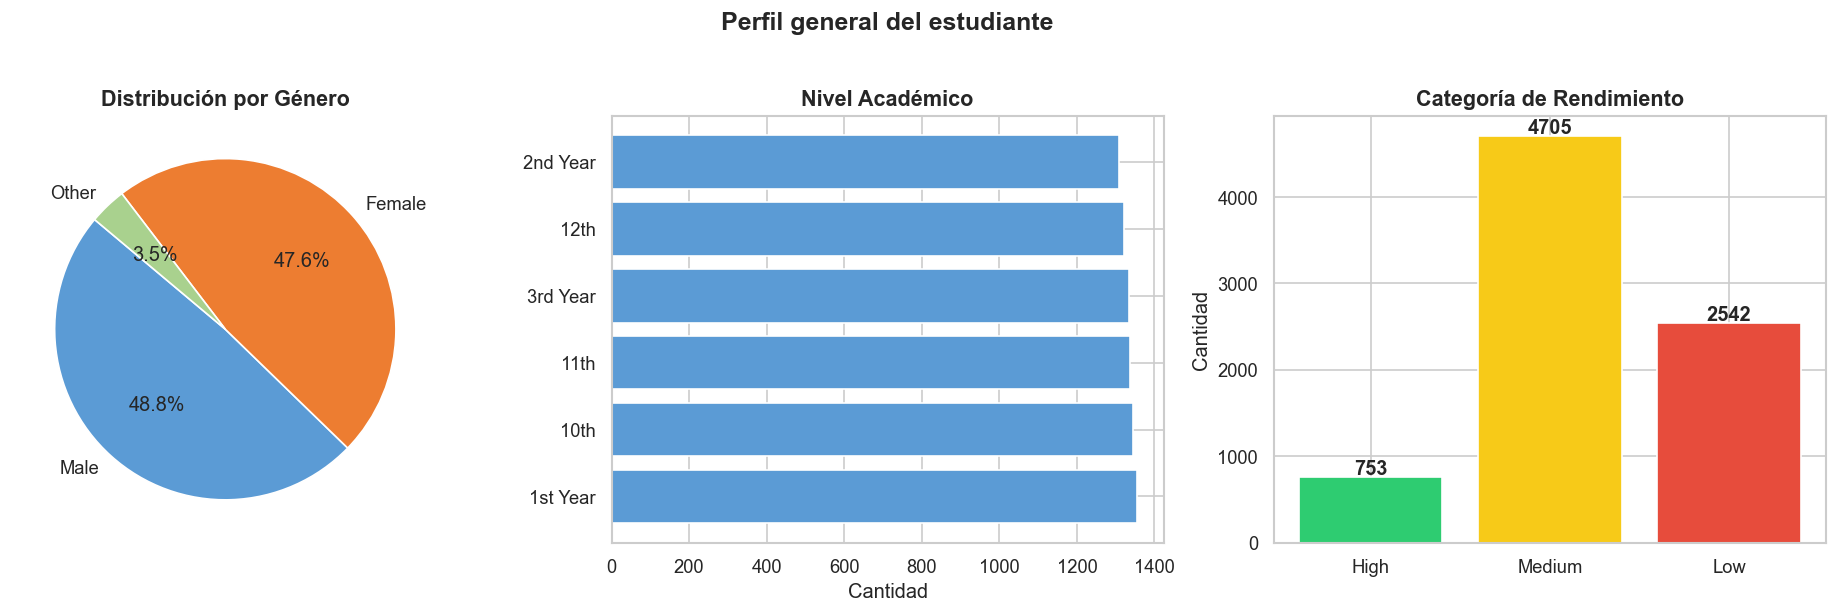

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Género
gender_counts = df['gender'].value_counts()
axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#5b9bd5','#ed7d31','#a9d18e'], startangle=140)
axes[0].set_title('Distribución por Género')

# Nivel académico
grade_counts = df['grade_level'].value_counts()
axes[1].barh(grade_counts.index, grade_counts.values,
             color='#5b9bd5', edgecolor='white')
axes[1].set_title('Nivel Académico')
axes[1].set_xlabel('Cantidad')

# Rendimiento
perf_counts = df['performance_category'].value_counts().reindex(['High','Medium','Low'])
axes[2].bar(perf_counts.index, perf_counts.values,
            color=['#2ecc71','#f7ca18','#e74c3c'], edgecolor='white')
axes[2].set_title('Categoría de Rendimiento')
axes[2].set_ylabel('Cantidad')
for i, v in enumerate(perf_counts.values):
    axes[2].text(i, v + 30, str(v), ha='center', fontweight='bold')

plt.suptitle('Perfil general del estudiante', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Uso de la IA — ¿Quién la usa y cómo?

In [6]:
# % que usa IA
usa_ia = df['uses_ai'].value_counts(normalize=True) * 100
print(f"Usan IA: {usa_ia.get(1, 0):.1f}%")
print(f"No usan IA: {usa_ia.get(0, 0):.1f}%")

Usan IA: 64.1%
No usan IA: 35.9%


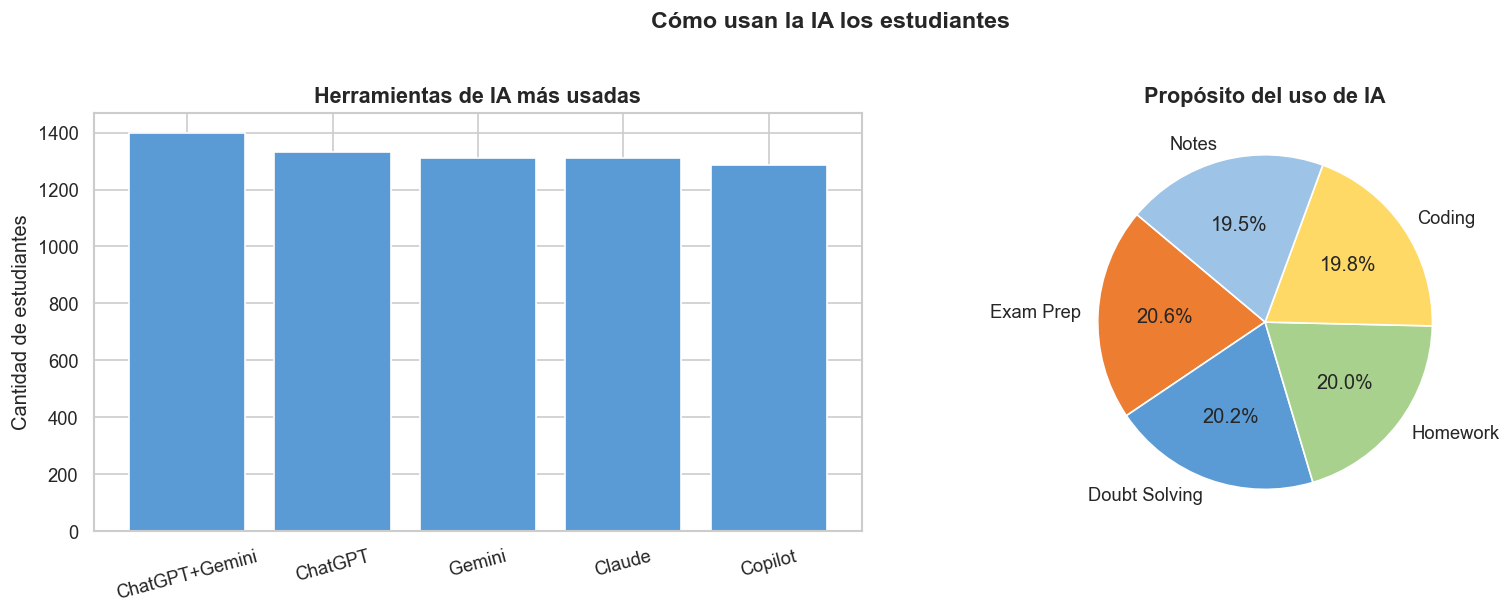

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Herramientas más usadas
tools = df['ai_tools_used'].value_counts().dropna()
axes[0].bar(tools.index, tools.values, color='#5b9bd5', edgecolor='white')
axes[0].set_title('Herramientas de IA más usadas')
axes[0].set_ylabel('Cantidad de estudiantes')
axes[0].tick_params(axis='x', rotation=15)

# Propósito de uso
purpose = df['ai_usage_purpose'].value_counts().dropna()
colors_p = ['#ed7d31','#5b9bd5','#a9d18e','#ffd966','#9dc3e6']
axes[1].pie(purpose, labels=purpose.index, autopct='%1.1f%%',
            colors=colors_p, startangle=140)
axes[1].set_title('Propósito del uso de IA')

plt.suptitle('Cómo usan la IA los estudiantes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

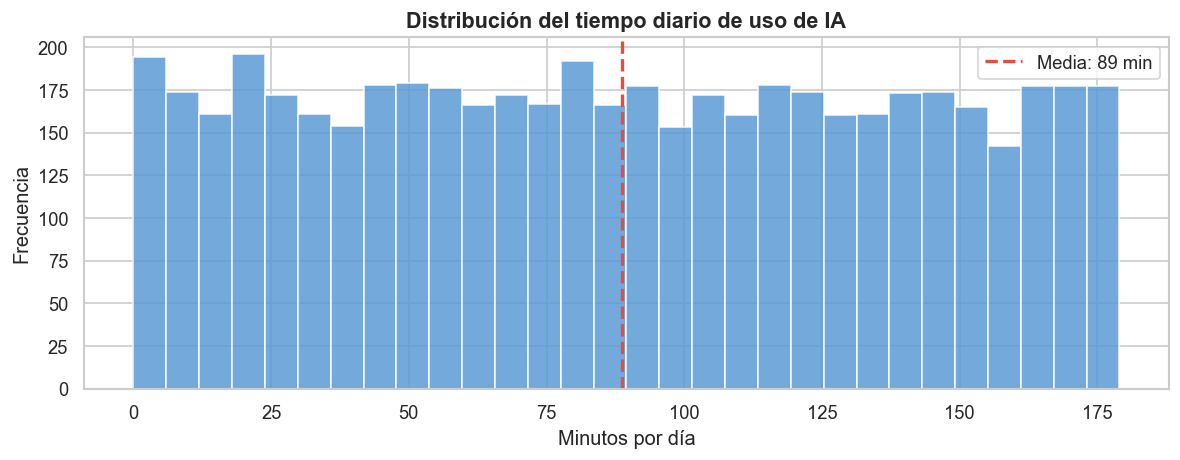

In [13]:
# Distribución del tiempo de uso de IA (minutos por día)
ai_users = df[df['uses_ai'] == 1]

plt.figure(figsize=(10, 4))
plt.hist(ai_users['ai_usage_time_minutes'], bins=30,
         color='#5b9bd5', edgecolor='white', alpha=0.85)
plt.axvline(ai_users['ai_usage_time_minutes'].mean(), color='#e74c3c',
            linestyle='--', linewidth=2,
            label=f"Media: {ai_users['ai_usage_time_minutes'].mean():.0f} min")
plt.title('Distribución del tiempo diario de uso de IA')
plt.xlabel('Minutos por día')
plt.ylabel('Frecuencia')
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Impacto de la IA en el rendimiento académico

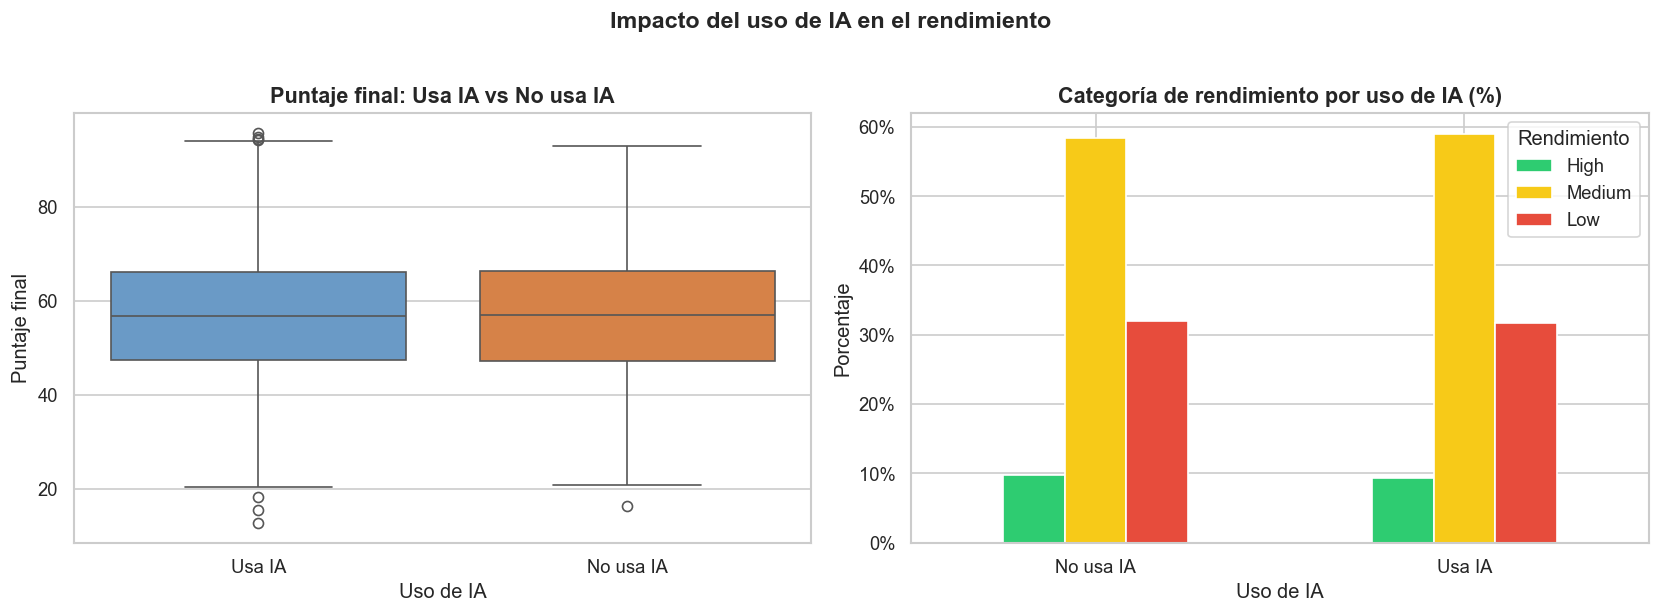

In [14]:
# Comparación de puntaje final: usuarios IA vs no usuarios
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
df['Uso de IA'] = df['uses_ai'].map({1: 'Usa IA', 0: 'No usa IA'})
sns.boxplot(data=df, x='Uso de IA', y='final_score',
            palette={'Usa IA': '#5b9bd5', 'No usa IA': '#ed7d31'},
            ax=axes[0])
axes[0].set_title('Puntaje final: Usa IA vs No usa IA')
axes[0].set_ylabel('Puntaje final')

# Rendimiento por categoría de uso de IA
perf_ia = df.groupby(['Uso de IA', 'performance_category']).size().unstack(fill_value=0)
perf_ia_pct = perf_ia.div(perf_ia.sum(axis=1), axis=0) * 100
perf_ia_pct[['High','Medium','Low']].plot(
    kind='bar', ax=axes[1], color=['#2ecc71','#f7ca18','#e74c3c'],
    edgecolor='white')
axes[1].set_title('Categoría de rendimiento por uso de IA (%)')
axes[1].set_ylabel('Porcentaje')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Rendimiento')

plt.suptitle('Impacto del uso de IA en el rendimiento', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

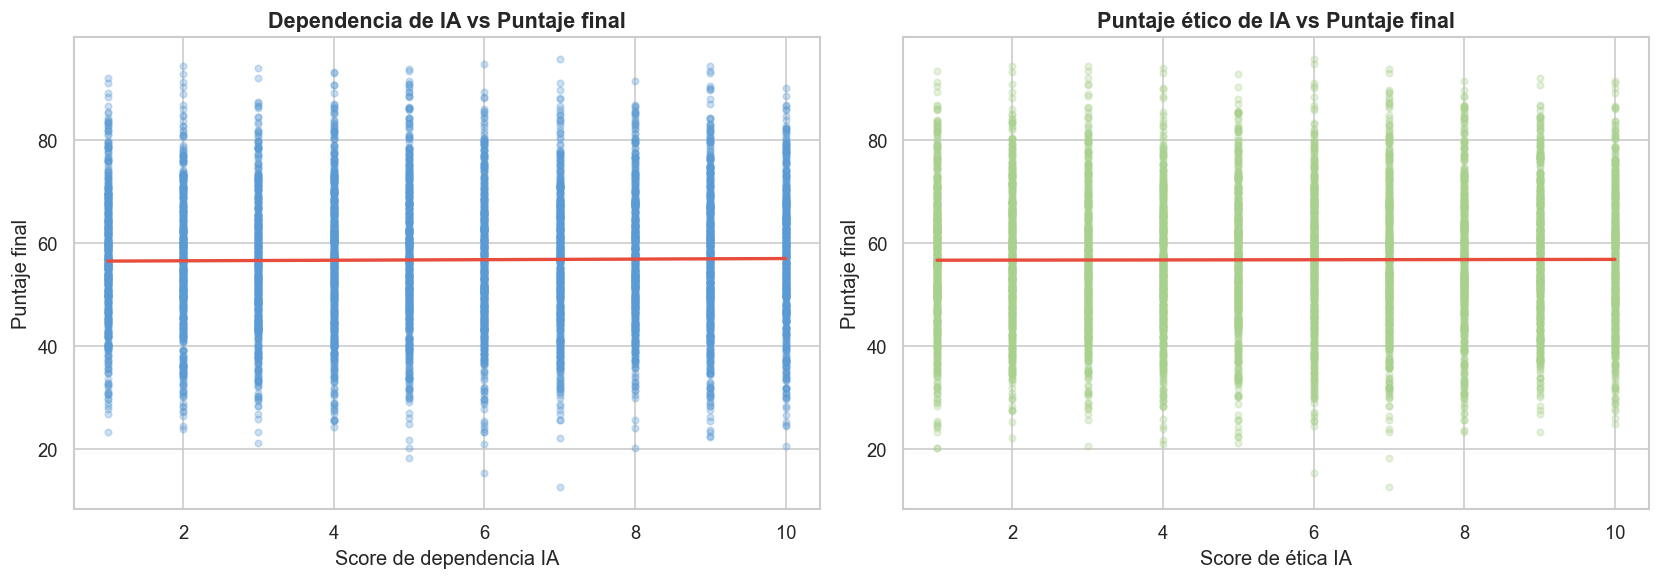

In [15]:
# Correlación: dependencia de IA vs puntaje final
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ai_users = df[df['uses_ai'] == 1]

# Dependencia vs puntaje
axes[0].scatter(ai_users['ai_dependency_score'], ai_users['final_score'],
                alpha=0.3, color='#5b9bd5', s=15)
m, b = np.polyfit(ai_users['ai_dependency_score'], ai_users['final_score'], 1)
x_line = np.linspace(ai_users['ai_dependency_score'].min(), ai_users['ai_dependency_score'].max())
axes[0].plot(x_line, m*x_line + b, color='#e74c3c', linewidth=2)
axes[0].set_title('Dependencia de IA vs Puntaje final')
axes[0].set_xlabel('Score de dependencia IA')
axes[0].set_ylabel('Puntaje final')

# Ética de IA vs puntaje
axes[1].scatter(ai_users['ai_ethics_score'], ai_users['final_score'],
                alpha=0.3, color='#a9d18e', s=15)
m2, b2 = np.polyfit(ai_users['ai_ethics_score'], ai_users['final_score'], 1)
x_line2 = np.linspace(ai_users['ai_ethics_score'].min(), ai_users['ai_ethics_score'].max())
axes[1].plot(x_line2, m2*x_line2 + b2, color='#e74c3c', linewidth=2)
axes[1].set_title('Puntaje ético de IA vs Puntaje final')
axes[1].set_xlabel('Score de ética IA')
axes[1].set_ylabel('Puntaje final')

plt.tight_layout()
plt.show()

---
## 6. Hábitos del estudiante — Sueño, estudio y redes sociales

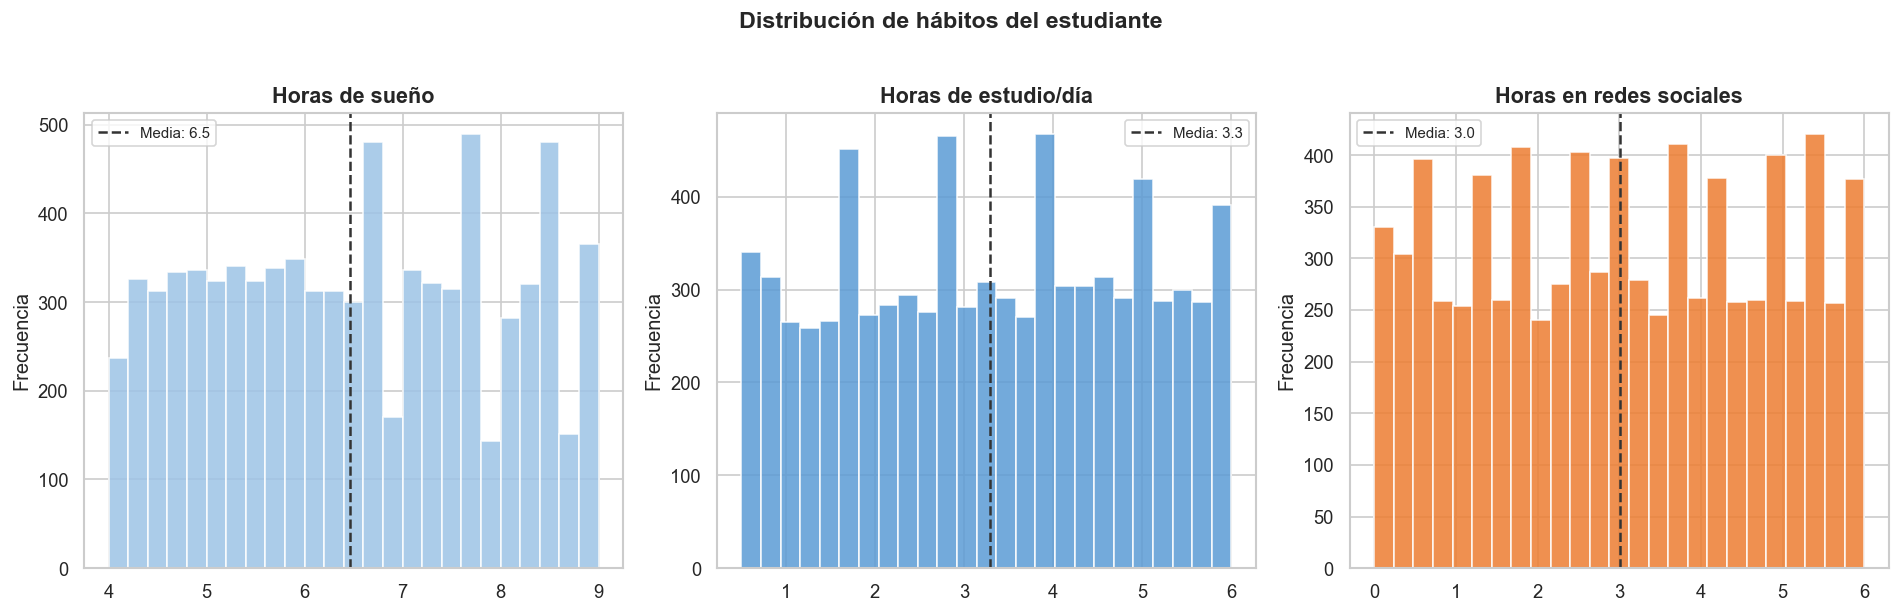

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
habit_cols = ['sleep_hours', 'study_hours_per_day', 'social_media_hours']
habit_labels = ['Horas de sueño', 'Horas de estudio/día', 'Horas en redes sociales']
habit_colors = ['#9dc3e6', '#5b9bd5', '#ed7d31']

for ax, col, label, color in zip(axes, habit_cols, habit_labels, habit_colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='#333', linestyle='--', linewidth=1.5,
               label=f'Media: {df[col].mean():.1f}')
    ax.set_title(label)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.suptitle('Distribución de hábitos del estudiante', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

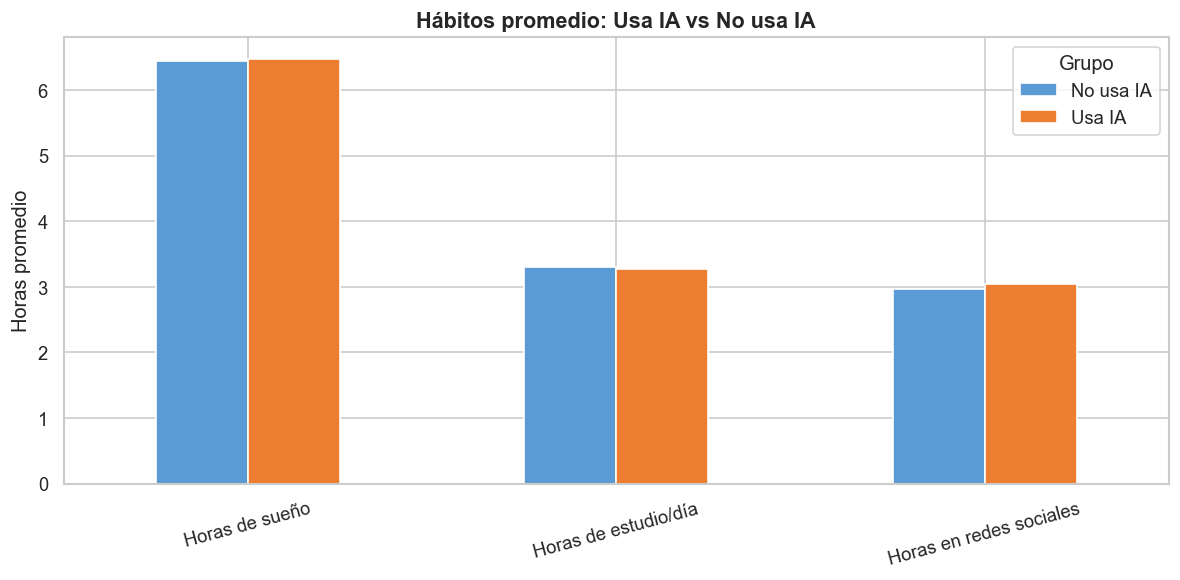

In [16]:
# Comparación de hábitos: usa IA vs no usa IA
habit_compare = df.groupby('Uso de IA')[habit_cols].mean().T
habit_compare.index = habit_labels
habit_compare.plot(kind='bar', figsize=(10, 5),
                   color=['#5b9bd5','#ed7d31'], edgecolor='white')
plt.title('Hábitos promedio: Usa IA vs No usa IA', fontweight='bold')
plt.ylabel('Horas promedio')
plt.xticks(rotation=15)
plt.legend(title='Grupo')
plt.tight_layout()
plt.show()

---
## 7. Mapa de correlaciones

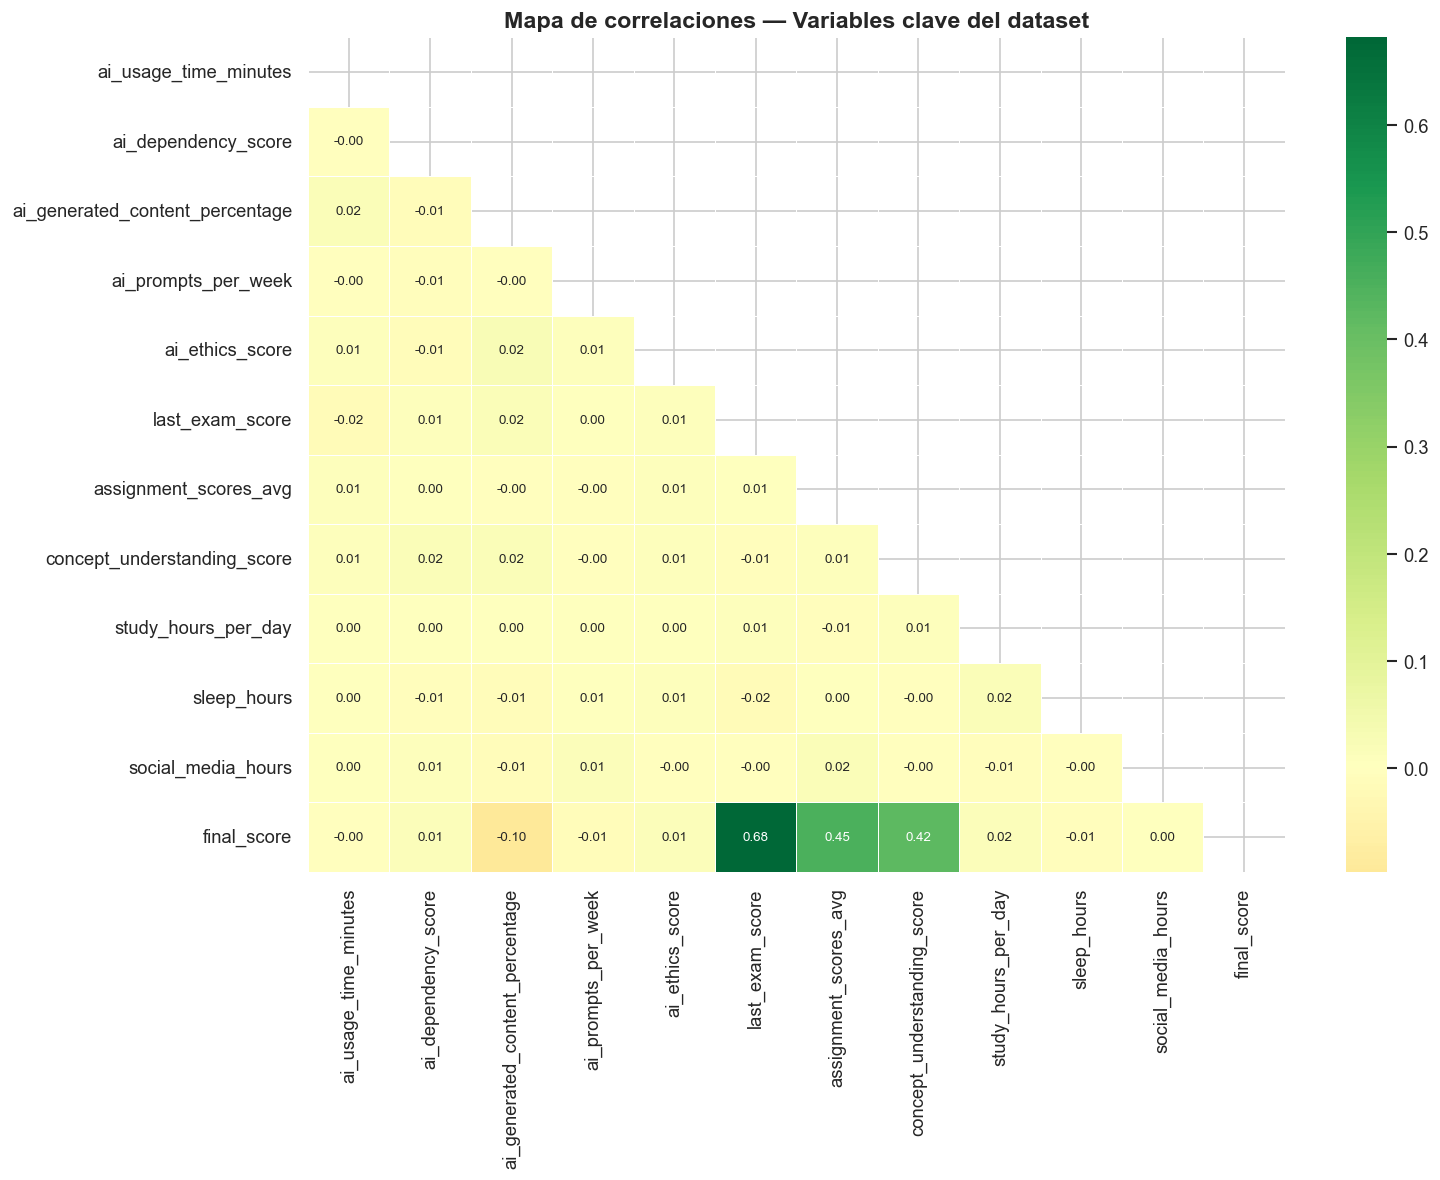

In [17]:
corr_cols = [
    'ai_usage_time_minutes', 'ai_dependency_score',
    'ai_generated_content_percentage', 'ai_prompts_per_week',
    'ai_ethics_score', 'last_exam_score', 'assignment_scores_avg',
    'concept_understanding_score', 'study_hours_per_day',
    'sleep_hours', 'social_media_hours', 'final_score'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5,
            annot_kws={'size': 8})
plt.title('Mapa de correlaciones — Variables clave del dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Tabla resumen por rendimiento académico

In [18]:
summary = df.groupby('performance_category').agg(
    n_estudiantes=('student_id', 'count'),
    pct_usa_ia=('uses_ai', lambda x: f"{x.mean()*100:.1f}%"),
    tiempo_ia_min=('ai_usage_time_minutes', 'mean'),
    dependencia_ia=('ai_dependency_score', 'mean'),
    etica_ia=('ai_ethics_score', 'mean'),
    horas_estudio=('study_hours_per_day', 'mean'),
    horas_sueno=('sleep_hours', 'mean'),
    redes_sociales=('social_media_hours', 'mean'),
    puntaje_final=('final_score', 'mean')
).round(2).reindex(['High','Medium','Low'])

print('=== Resumen por categoría de rendimiento ===')
summary

=== Resumen por categoría de rendimiento ===


,n_estudiantes,pct_usa_ia,tiempo_ia_min,dependencia_ia,etica_ia,horas_estudio,horas_sueno,redes_sociales,puntaje_final
performance_category,,,,,,,,,
High,753,63.1%,88.60,5.69,5.56,3.38,6.39,3.03,80.70
Medium,4705,64.4%,89.05,5.48,5.50,3.29,6.47,3.01,61.24
Low,2542,63.9%,88.99,5.52,5.39,3.26,6.47,3.01,41.54


---
## 9. Dataset 3 - Percepcion de reemplazo por IA y nivel de agotamiento

Los siguientes 4 graficos de dispersion analizan la relacion entre la percepcion de reemplazo por IA y el nivel de agotamiento, uno por celda.
Se utiliza el dataset original Data_set_03.csv, con las variables ai_replaces_my_tasks_pct y burnout_score (presentada como nivel de agotamiento).

Cada grafico incluye media, mediana, desviacion estandar y correlacion para facilitar la interpretacion estadistica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Dataset usado
df_ds3 = pd.read_csv('./Data/Data_set_03.csv')

# Se usan las 4 profesiones mas repetidas del dataset
profesiones = df_ds3['job_role'].value_counts().head(4).index.tolist()

def graficar_profesion(df, profesion):
    df_prof = df[df['job_role'] == profesion]

    x = df_prof['ai_replaces_my_tasks_pct']
    y = df_prof['burnout_score']

    y_mean = y.mean()
    y_std = y.std(ddof=1)
    y_median = y.median()
    corr = x.corr(y)

    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    y_line = m * x_line + b

    plt.figure(figsize=(8, 6))
    plt.scatter(x, y, s=34, color='#2f5597', alpha=0.35, edgecolors='none', label='Observaciones')
    plt.plot(x_line, y_line, color='#c23b22', linewidth=2.2, label='Tendencia lineal')

    plt.axhline(y_mean, color='#a61c00', linewidth=2.2, label=f'Media = {y_mean:.2f}')
    plt.axhline(y_median, color='#38761d', linestyle='--', linewidth=2.2, label=f'Mediana = {y_median:.2f}')
    plt.axhline(y_mean - y_std, color='#ed7d31', linestyle=':', linewidth=2)
    plt.axhline(y_mean + y_std, color='#ed7d31', linestyle=':', linewidth=2, label=f'Desv. est. = {y_std:.2f}')

    plt.text(
        0.02, 0.98,
        f'n = {len(df_prof)}\nMedia = {y_mean:.2f}\nMediana = {y_median:.2f}\nDesv. est. = {y_std:.2f}\nCorrelacion r = {corr:.3f}',
        transform=plt.gca().transAxes,
        va='top',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#b7b7b7')
    )

    plt.title(f'Percepcion de reemplazo por IA vs nivel de agotamiento\n{profesion}')
    plt.xlabel('Percepcion de reemplazo por IA (%)')
    plt.ylabel('Nivel de agotamiento')
    plt.grid(True, alpha=0.25)
    plt.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    plt.show()

print('Profesiones seleccionadas:')
for i, profesion in enumerate(profesiones, start=1):
    print(f'{i}. {profesion}')

Profesiones seleccionadas:
1. Software Engineer
2. AI Researcher
3. Data Scientist
4. AI Ethics Officer


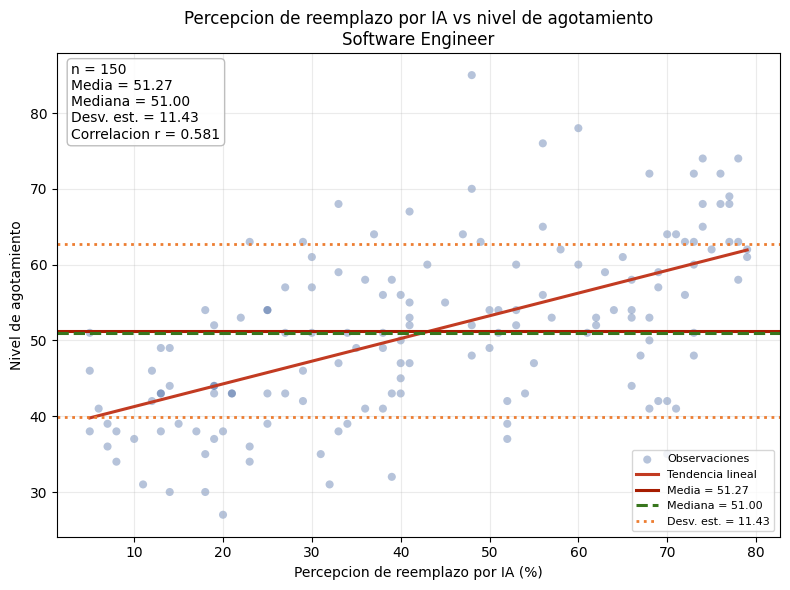

In [7]:
# Grafico 1
graficar_profesion(df_ds3, profesiones[0])

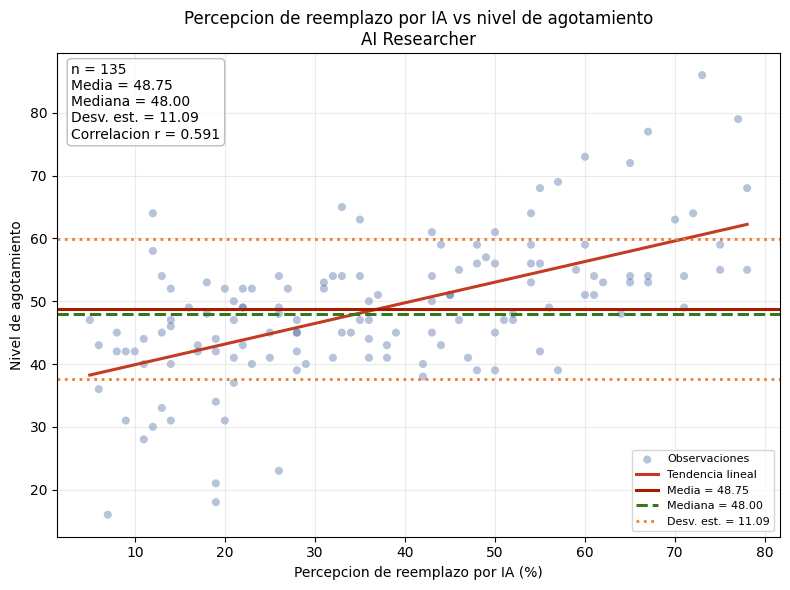

In [8]:
# Grafico 2
graficar_profesion(df_ds3, profesiones[1])

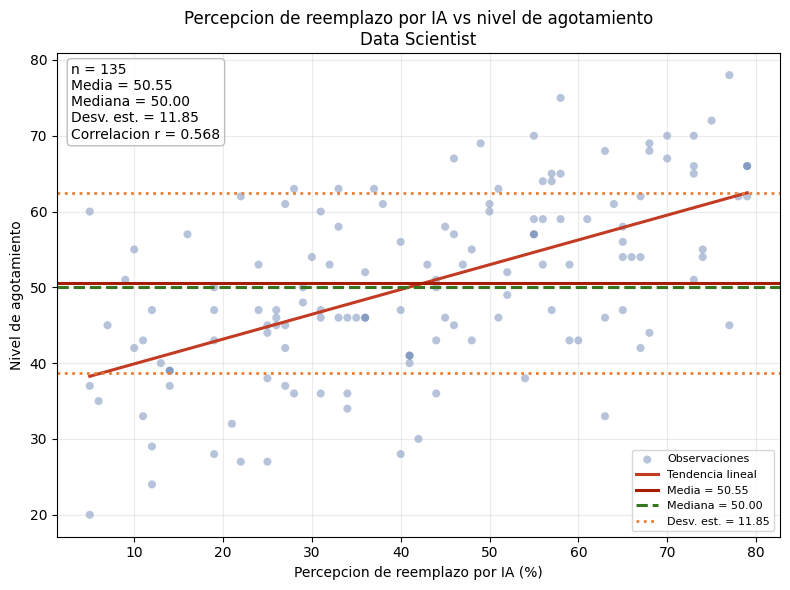

In [9]:
# Grafico 3
graficar_profesion(df_ds3, profesiones[2])

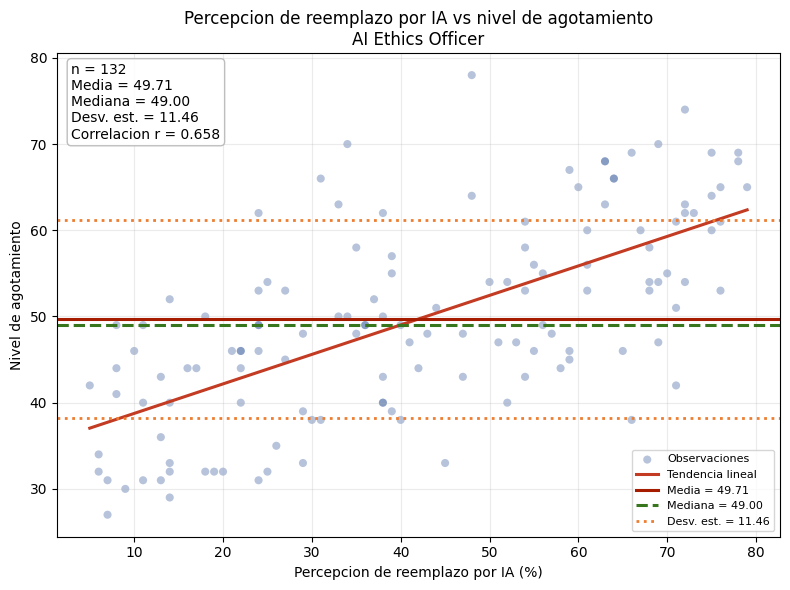

In [10]:
# Grafico 4
graficar_profesion(df_ds3, profesiones[3])

### Casilla de interpretacion simple

En los 4 graficos se observa una tendencia positiva: cuando sube la percepcion de reemplazo por IA, tambien sube el nivel de agotamiento.

Interpretacion rapida por profesion:
- Software Engineer: es el grupo con mayor agotamiento promedio (media = 51.27).
- AI Researcher: muestra el menor agotamiento promedio (media = 48.75).
- Data Scientist: tiene un nivel intermedio de agotamiento (media = 50.55) y la correlacion mas baja (r = 0.568).
- AI Ethics Officer: es donde mas fuerte se relaciona el miedo al reemplazo con el agotamiento (correlacion r = 0.658).


- Si miramos quien se siente peor en promedio, es Software Engineer.
- Si miramos quien se siente menos afectado en promedio, es AI Researcher.
- Si miramos a quien le afecta mas la idea de reemplazo de IA, es AI Ethics Officer.


---
## 10. OECD Data Explorer API (JSON) - IA por pais

> Objetivo: descargar datos de la API de OECD en formato JSON, convertirlos a tabla util y guardar un JSON limpio para analisis en el proyecto.

JSON crudo guardado en: Data\oecd_ai_patents_2020_raw.json
JSON limpio guardado en: Data\oecd_ai_patents_2020_clean.json
Paises con valor > 0: 172


,iso3,country,year,ai_patents_value
0,USA,United States,2020,4548.8960
1,USA,United States,2021,4390.9629
2,CHN,China (People’s Republic of),2020,3590.7998
3,CHN,China (People’s Republic of),2021,3320.1160
4,USA,United States,2022,3078.0203
5,JPN,Japan,2020,3031.1582
6,JPN,Japan,2021,2765.0000
7,CHN,China (People’s Republic of),2022,2696.4976
8,KOR,Korea,2022,2195.1667
9,JPN,Japan,2022,2189.7595


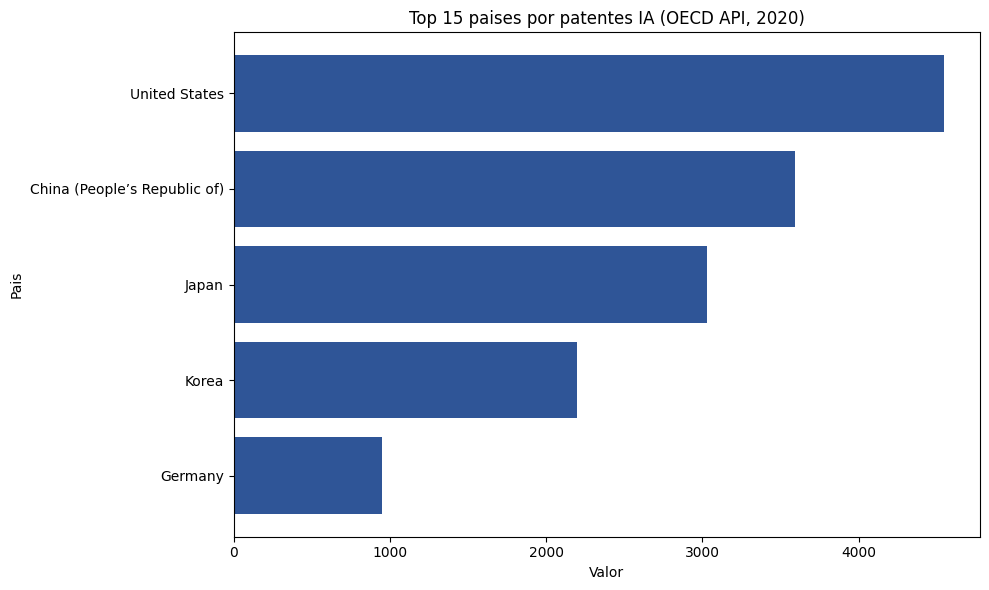

In [2]:
import json
import urllib.request
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# API JSON desde OECD Data Explorer (IA por pais, 2020, familias de patentes IP5)
api_url = (
    "https://sdmx.oecd.org/public/rest/data/"
    "OECD.STI.PIE,DSD_PATENTS%40DF_PATENTS_OECDSPECIFIC/"
    "9P50_3.A.PF.PATN_FM.PRIORITY.._Z.APPLICANT._Z._Z.AI"
    "?startPeriod=2020&dimensionAtObservation=AllDimensions&format=jsondata"
)

# Algunas instancias de la API rechazan requests sin User-Agent
request = urllib.request.Request(
    api_url,
    headers={
        "User-Agent": "Mozilla/5.0",
        "Accept": "application/json",
    },
)

with urllib.request.urlopen(request) as response:
    payload = json.loads(response.read().decode("utf-8"))

# Guardar JSON crudo para trazabilidad
raw_json_path = Path("./Data/oecd_ai_patents_2020_raw.json")
raw_json_path.write_text(
    json.dumps(payload, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

# Parseo SDMX-JSON -> tabla plana
if "structure" in payload.get("data", {}):
    obs_dims = payload["data"]["structure"]["dimensions"]["observation"]
else:
    obs_dims = payload["data"]["structures"][0]["dimensions"]["observation"]

dim_ids = [d["id"] for d in obs_dims]
dim_values = [d["values"] for d in obs_dims]

records = []
for obs_key, obs_val in payload["data"]["dataSets"][0]["observations"].items():
    idx = [int(i) for i in obs_key.split(":")]
    rec = {}
    for i, dim_id in enumerate(dim_ids):
        selected = dim_values[i][idx[i]]
        rec[dim_id] = selected.get("id")
        rec[f"{dim_id}_label"] = selected.get("name")

    rec["OBS_VALUE"] = obs_val[0] if len(obs_val) > 0 else None
    records.append(rec)

df_oecd = pd.DataFrame(records)
df_oecd["OBS_VALUE"] = pd.to_numeric(df_oecd["OBS_VALUE"], errors="coerce")

# Limpieza para analisis georreferenciado:
# - solo paises ISO3
# - quitar valores nulos o cero
df_oecd_clean = (
    df_oecd.loc[
        df_oecd["REF_AREA"].str.fullmatch(r"[A-Z]{3}", na=False)
        & df_oecd["OBS_VALUE"].notna()
        & (df_oecd["OBS_VALUE"] > 0),
        ["REF_AREA", "REF_AREA_label", "TIME_PERIOD", "OBS_VALUE"],
    ]
    .rename(
        columns={
            "REF_AREA": "iso3",
            "REF_AREA_label": "country",
            "TIME_PERIOD": "year",
            "OBS_VALUE": "ai_patents_value",
        }
    )
    .sort_values("ai_patents_value", ascending=False)
    .reset_index(drop=True)
)

# Guardar JSON limpio (listo para app, informe o mapas)
clean_json_path = Path("./Data/oecd_ai_patents_2020_clean.json")
clean_json_path.write_text(
    df_oecd_clean.to_json(orient="records", force_ascii=False, indent=2),
    encoding="utf-8",
)

print(f"JSON crudo guardado en: {raw_json_path}")
print(f"JSON limpio guardado en: {clean_json_path}")
print(f"Paises con valor > 0: {len(df_oecd_clean)}")
display(df_oecd_clean.head(12))

# Visual rapida: top 15 paises
top15 = df_oecd_clean.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top15["country"], top15["ai_patents_value"], color="#2f5597")
plt.title("Top 15 paises por patentes IA (OECD API, 2020)")
plt.xlabel("Valor")
plt.ylabel("Pais")
plt.tight_layout()
plt.show()

## Graficos con datos de Hugging Face

Se agregan dos visualizaciones al final del notebook usando los archivos locales de la carpeta `Data/huggingface_ia`.

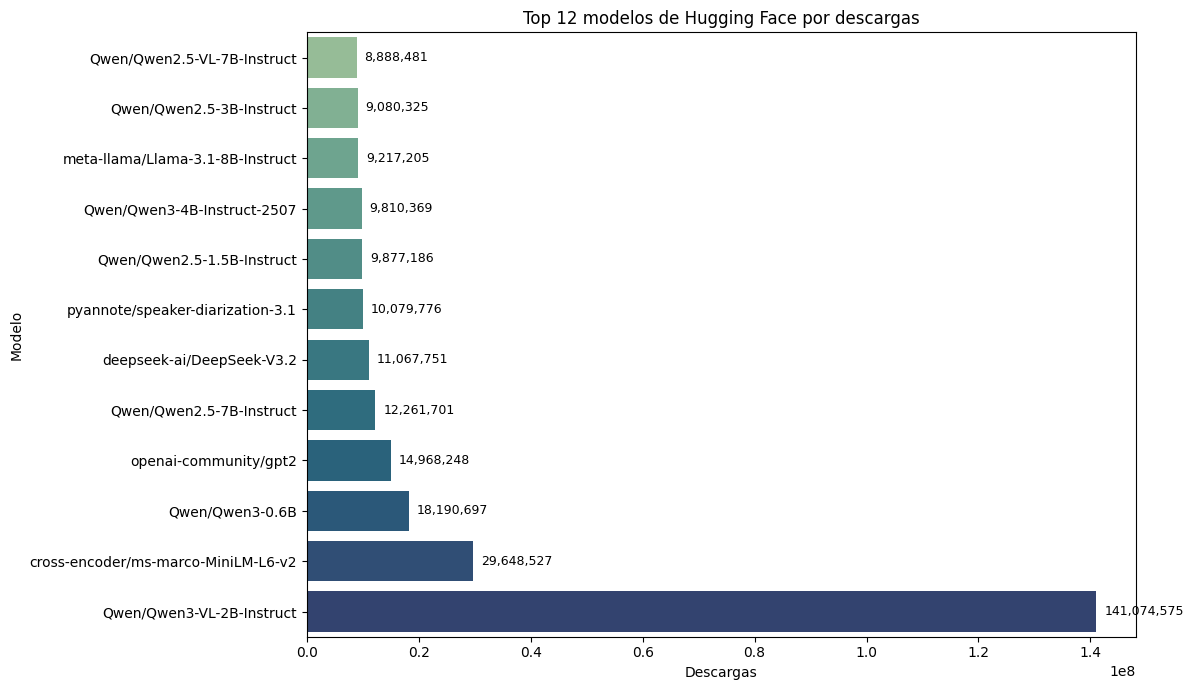

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

hf_models_path = Path("Data/huggingface_ia/huggingface_models_ia.csv")
df_models = pd.read_csv(hf_models_path, low_memory=False)

df_models["downloads"] = pd.to_numeric(df_models["downloads"], errors="coerce")
df_models = df_models.dropna(subset=["modelId", "downloads"]).copy()

df_top_models = (
    df_models.sort_values("downloads", ascending=False)
    .head(12)
    .sort_values("downloads", ascending=True)
    .copy()
)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=df_top_models,
    x="downloads",
    y="modelId",
    palette="crest",
    hue="modelId",
    dodge=False,
    legend=False,
)
plt.title("Top 12 modelos de Hugging Face por descargas")
plt.xlabel("Descargas")
plt.ylabel("Modelo")

offset = df_top_models["downloads"].max() * 0.01
for i, value in enumerate(df_top_models["downloads"]):
    plt.text(value + offset, i, f"{int(value):,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

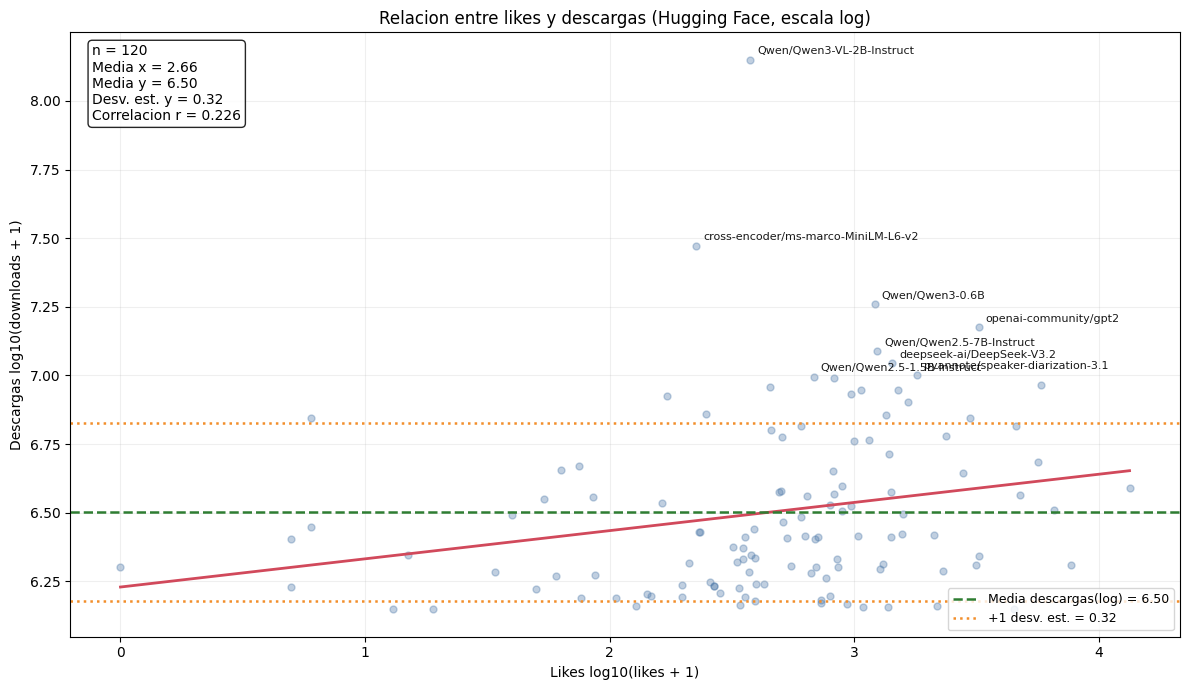

In [5]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

hf_models_path = Path("Data/huggingface_ia/huggingface_models_ia.csv")
df_models = pd.read_csv(hf_models_path, low_memory=False)
df_models["downloads"] = pd.to_numeric(df_models["downloads"], errors="coerce")
df_models["likes"] = pd.to_numeric(df_models["likes"], errors="coerce")

df_scatter = df_models.dropna(subset=["modelId", "likes", "downloads"]).copy()
df_scatter = df_scatter[(df_scatter["downloads"] > 0) & (df_scatter["likes"] >= 0)].copy()

df_scatter["likes_log"] = np.log10(df_scatter["likes"] + 1)
df_scatter["downloads_log"] = np.log10(df_scatter["downloads"] + 1)

x = df_scatter["likes_log"]
y = df_scatter["downloads_log"]
corr = x.corr(y)
x_mean, y_mean = x.mean(), y.mean()
y_std = y.std(ddof=1)

fig, ax = plt.subplots(figsize=(12, 7))
sns.regplot(
    data=df_scatter,
    x="likes_log",
    y="downloads_log",
    scatter_kws={"alpha": 0.35, "s": 25, "color": "#4C78A8"},
    line_kws={"color": "#D1495B", "linewidth": 2},
    ci=None,
    ax=ax,
 )

ax.axhline(y_mean, color="#2E7D32", linestyle="--", linewidth=1.8, label=f"Media descargas(log) = {y_mean:.2f}")
ax.axhline(y_mean + y_std, color="#F28E2B", linestyle=":", linewidth=1.8, label=f"+1 desv. est. = {y_std:.2f}")
ax.axhline(y_mean - y_std, color="#F28E2B", linestyle=":", linewidth=1.8)

top_label = df_scatter.sort_values("downloads", ascending=False).head(8)
for _, row in top_label.iterrows():
    ax.annotate(
        row["modelId"],
        (row["likes_log"], row["downloads_log"]),
        textcoords="offset points",
        xytext=(5, 4),
        fontsize=8,
        alpha=0.9,
    )

stats_text = (
    f"n = {len(df_scatter)}\n"
    f"Media x = {x_mean:.2f}\n"
    f"Media y = {y_mean:.2f}\n"
    f"Desv. est. y = {y_std:.2f}\n"
    f"Correlacion r = {corr:.3f}"
)
ax.text(
    0.02, 0.98, stats_text,
    transform=ax.transAxes,
    va="top",
    fontsize=10,
    bbox={"boxstyle": "round", "facecolor": "white", "alpha": 0.85},
)

ax.set_title("Relacion entre likes y descargas (Hugging Face, escala log)")
ax.set_xlabel("Likes log10(likes + 1)")
ax.set_ylabel("Descargas log10(downloads + 1)")
ax.grid(alpha=0.2)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

---
## 11. Graficos OECD desde Data/ocde_ia

> Esta seccion recrea 6 graficos en base a los CSV limpios descargados por la API OECD.
Los graficos se guardan en `graficos_api_ocde/` con los mismos nombres que ya tenias.

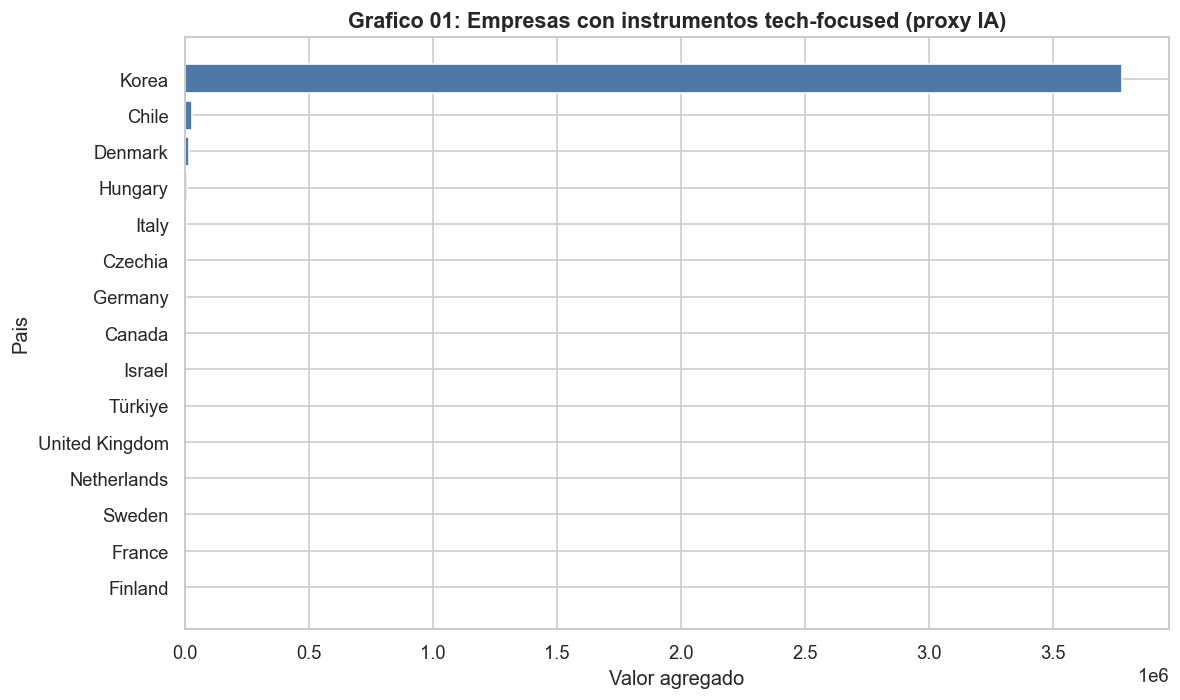

[OK] Guardado: graficos_api_ocde\ocde_grafico_01_empresas_ia.png


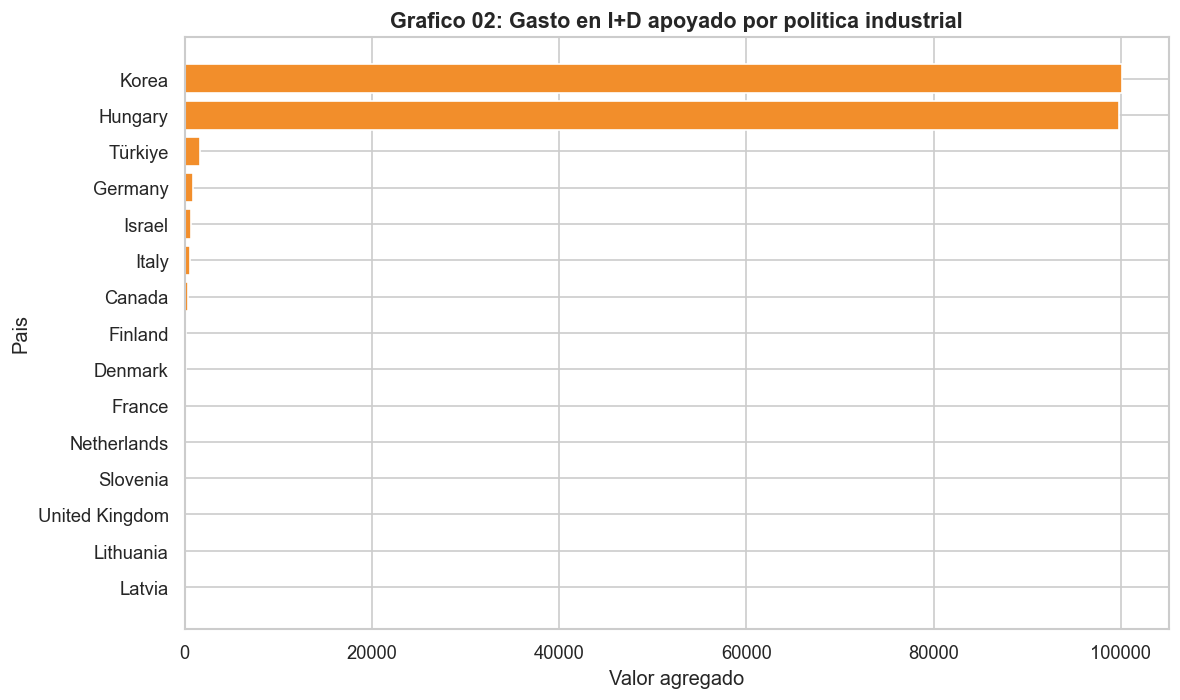

[OK] Guardado: graficos_api_ocde\ocde_grafico_02_gasto_id.png


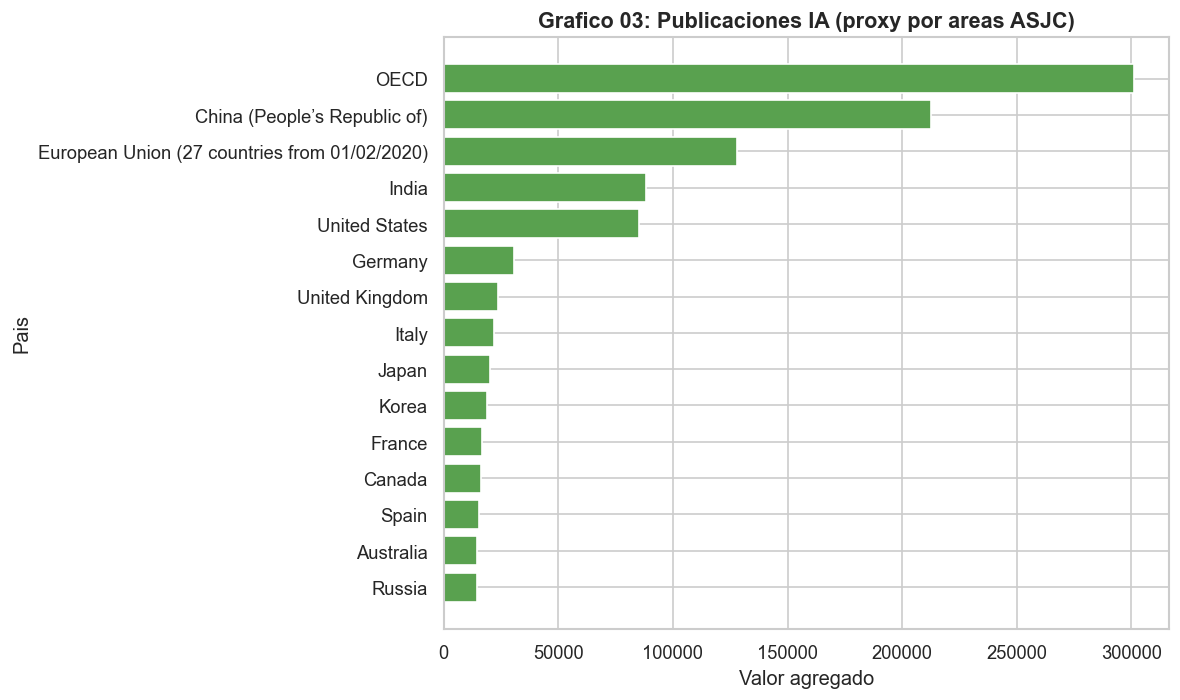

[OK] Guardado: graficos_api_ocde\ocde_grafico_03_publicaciones_ia.png


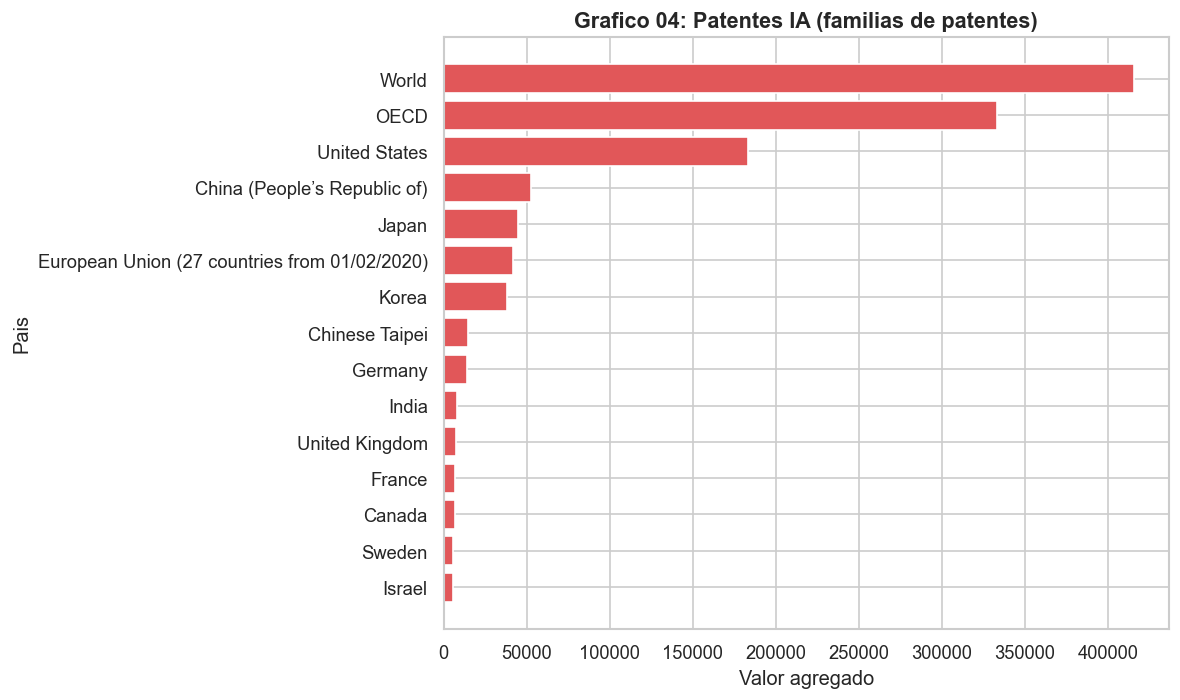

[OK] Guardado: graficos_api_ocde\ocde_grafico_04_patentes_ia.png


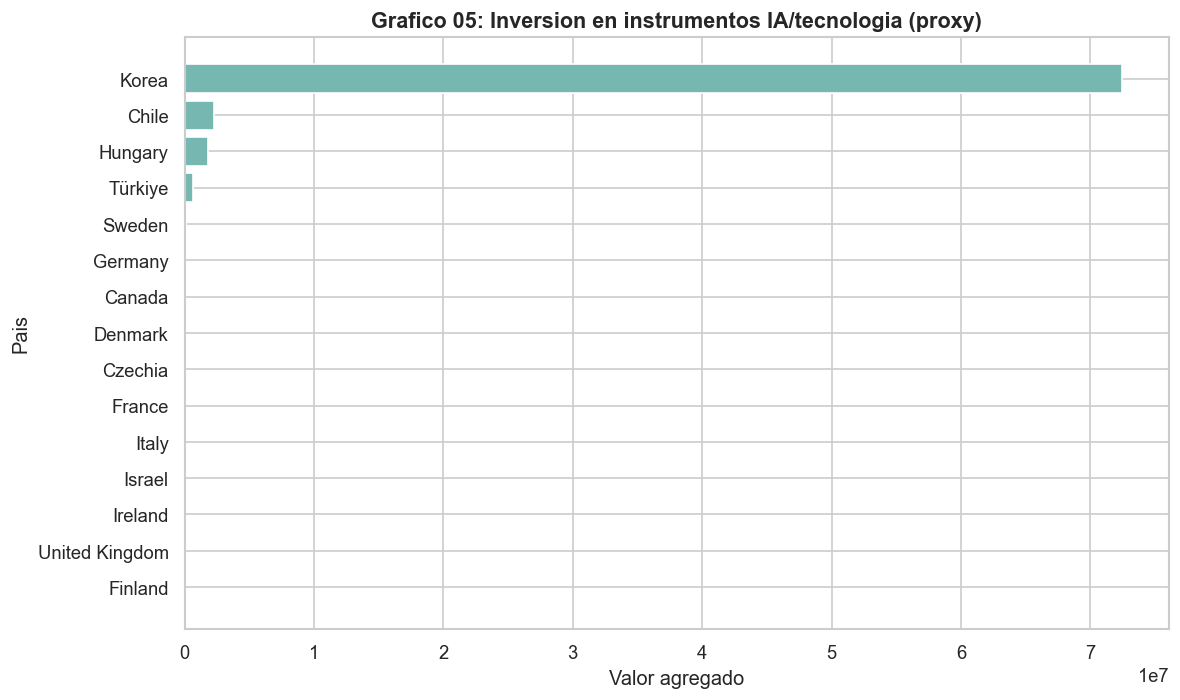

[OK] Guardado: graficos_api_ocde\ocde_grafico_05_inversion_ia.png


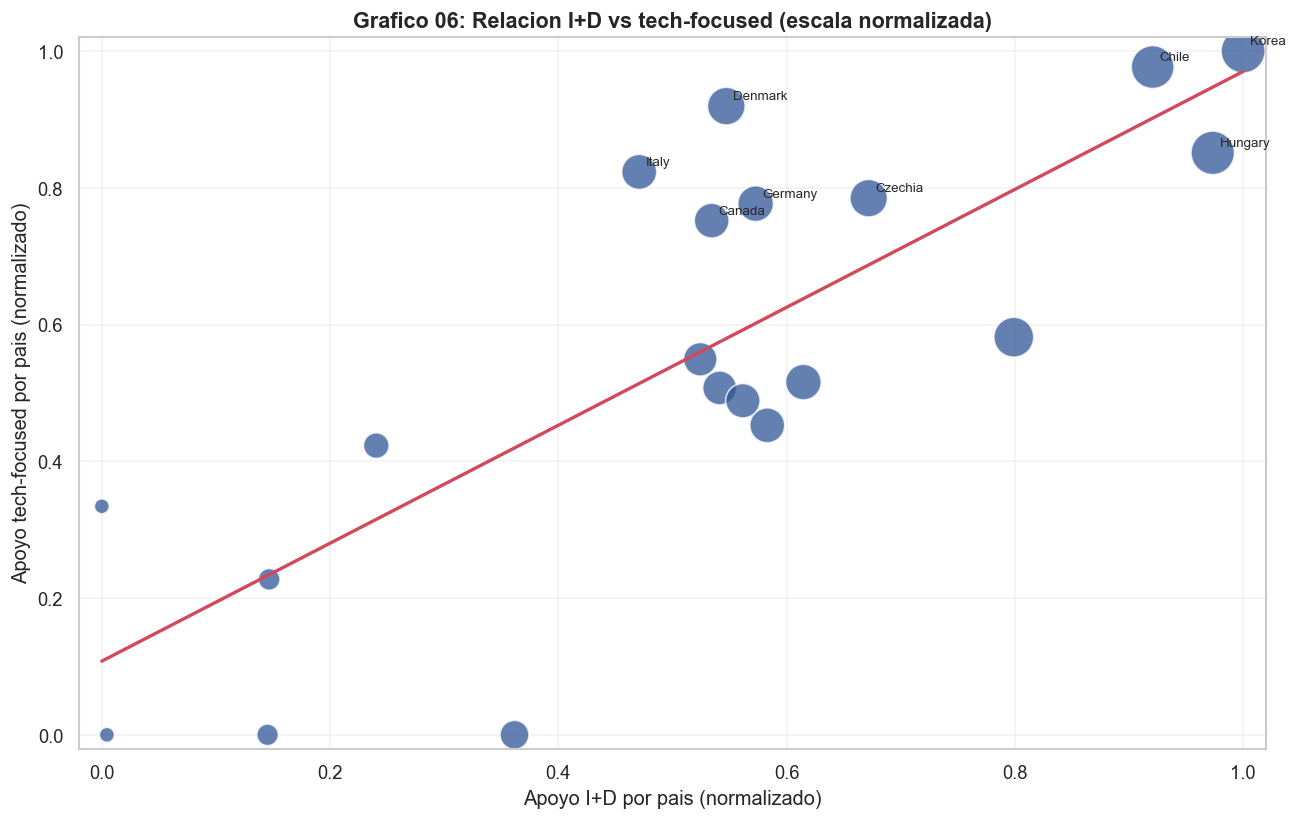

[OK] Guardado: graficos_api_ocde\ocde_grafico_06_rd_vs_ia.png
Correlacion logaritmica (r): 0.839

Graficos generados en: C:\Users\marti\Desktop\Computacion_Cientifica\Computacion-cientifica\graficos_api_ocde


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATA_OECD = Path("./Data/ocde_ia")
OUT_OECD = Path("./graficos_api_ocde")
OUT_OECD.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

def read_oecd_csv(filename: str, usecols: list[str] | None = None) -> pd.DataFrame:
    path = DATA_OECD / filename
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")
    return pd.read_csv(path, low_memory=False, usecols=usecols)

def to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors="coerce")

def filter_positive(df: pd.DataFrame, value_col: str = "OBS_VALUE") -> pd.DataFrame:
    out = df.copy()
    out[value_col] = to_numeric(out[value_col])
    return out[out[value_col].notna() & (out[value_col] > 0)].copy()

def latest_year(df: pd.DataFrame, year_col: str = "TIME_PERIOD") -> pd.DataFrame:
    if year_col not in df.columns:
        return df.copy()
    years = to_numeric(df[year_col]).dropna()
    if years.empty:
        return df.copy()
    return df[to_numeric(df[year_col]) == years.max()].copy()

def top_country_bar(
    df: pd.DataFrame,
    title: str,
    output_name: str,
    country_col: str = "REF_AREA_label",
    value_col: str = "OBS_VALUE",
    top_n: int = 15,
    color: str = "#2f5597",
) -> pd.DataFrame:
    if df.empty:
        print(f"[WARN] No hay datos para {output_name}")
        return pd.DataFrame()

    agg = (
        df.groupby(country_col, as_index=False)[value_col]
        .sum()
        .sort_values(value_col, ascending=False)
        .head(top_n)
    )

    plot_df = agg.sort_values(value_col, ascending=True)
    plt.figure(figsize=(10, 6))
    plt.barh(plot_df[country_col], plot_df[value_col], color=color, edgecolor="white")
    plt.title(title)
    plt.xlabel("Valor agregado")
    plt.ylabel("Pais")
    plt.tight_layout()

    out_path = OUT_OECD / output_name
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"[OK] Guardado: {out_path}")
    return agg

def remove_aggregate_areas(df: pd.DataFrame, area_col: str = "REF_AREA_label") -> pd.DataFrame:
    if area_col not in df.columns:
        return df.copy()

    blocked = {
        "oecd", "world", "european union", "euro area",
        "non-oecd economies", "not applicable",
    }
    area_lower = df[area_col].fillna("").astype(str).str.lower()
    mask = ~area_lower.str.contains("|".join(blocked), regex=True)
    return df.loc[mask].copy()

def minmax_robust(series: pd.Series, q_low: float = 0.05, q_high: float = 0.95) -> pd.Series:
    s = to_numeric(series).fillna(0)
    lo = s.quantile(q_low)
    hi = s.quantile(q_high)
    s_clip = s.clip(lower=lo, upper=hi)
    if hi <= lo:
        return pd.Series(np.zeros(len(s_clip)), index=s_clip.index)
    return (s_clip - lo) / (hi - lo)

# ===============================
# GRAFICO 01: EMPRESAS IA (proxy)
# ===============================
df_emp = read_oecd_csv(
    "dsd_industrial_policy_df_grantax_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "TECH_FOCUSED_label"],
)
df_emp = latest_year(filter_positive(df_emp))
emp_mask = df_emp["TECH_FOCUSED_label"].astype(str).str.lower().eq("yes")
df_emp_plot = df_emp.loc[emp_mask].copy()
if df_emp_plot.empty:
    df_emp_plot = df_emp.copy()

top_country_bar(
    df_emp_plot,
    title="Grafico 01: Empresas con instrumentos tech-focused (proxy IA)",
    output_name="ocde_grafico_01_empresas_ia.png",
    color="#4e79a7",
)

# ============================
# GRAFICO 02: GASTO EN I+D
# ============================
df_rd = read_oecd_csv(
    "dsd_industrial_policy_df_fin_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "RD_label"],
)
df_rd = latest_year(filter_positive(df_rd))
rd_mask = df_rd["RD_label"].astype(str).str.lower().eq("yes")
df_rd_plot = df_rd.loc[rd_mask].copy()
if df_rd_plot.empty:
    df_rd_plot = df_rd.copy()

top_country_bar(
    df_rd_plot,
    title="Grafico 02: Gasto en I+D apoyado por politica industrial",
    output_name="ocde_grafico_02_gasto_id.png",
    color="#f28e2b",
)

# =========================================
# GRAFICO 03: PUBLICACIONES IA (proxy bib)
# =========================================
df_pub = read_oecd_csv(
    "dsd_biblio_df_biblio_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "ASJC_label"],
)
df_pub = latest_year(filter_positive(df_pub))
asjc = df_pub["ASJC_label"].fillna("").astype(str).str.lower()
kw_pub = "artificial|machine|deep|neural|language|vision|data|comput"
df_pub_plot = df_pub[asjc.str.contains(kw_pub, regex=True)].copy()
if df_pub_plot.empty:
    df_pub_plot = df_pub.copy()

top_country_bar(
    df_pub_plot,
    title="Grafico 03: Publicaciones IA (proxy por areas ASJC)",
    output_name="ocde_grafico_03_publicaciones_ia.png",
    color="#59a14f",
)

# ===========================
# GRAFICO 04: PATENTES IA
# ===========================
df_pat = read_oecd_csv(
    "dsd_patents_df_patents_oecdspecific_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "OECD_TECHNOLOGY_PATENT_label"],
)
df_pat = latest_year(filter_positive(df_pat))
tech = df_pat["OECD_TECHNOLOGY_PATENT_label"].fillna("").astype(str).str.lower()
kw_pat = "artificial|machine|comput|digital|data|ict|software"
df_pat_plot = df_pat[tech.str.contains(kw_pat, regex=True)].copy()
if df_pat_plot.empty:
    df_pat_plot = df_pat.copy()

top_country_bar(
    df_pat_plot,
    title="Grafico 04: Patentes IA (familias de patentes)",
    output_name="ocde_grafico_04_patentes_ia.png",
    color="#e15759",
)

# ==================================
# GRAFICO 05: INVERSION IA (proxy)
# ==================================
df_inv = read_oecd_csv(
    "dsd_industrial_policy_df_fin_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "INSTRUMENT_TYPE_label"],
)
df_inv = latest_year(filter_positive(df_inv))
instr = df_inv["INSTRUMENT_TYPE_label"].fillna("").astype(str).str.lower()
kw_inv = "venture|equity|loan|capital|investment|fund"
df_inv_plot = df_inv[instr.str.contains(kw_inv, regex=True)].copy()
if df_inv_plot.empty:
    df_inv_plot = df_inv.copy()

top_country_bar(
    df_inv_plot,
    title="Grafico 05: Inversion en instrumentos IA/tecnologia (proxy)",
    output_name="ocde_grafico_05_inversion_ia.png",
    color="#76b7b2",
)

# =====================================
# GRAFICO 06: RELACION I+D VS IA (proxy)
# Escala normalizada para evitar outliers dominantes
# =====================================
df_fin_sc = read_oecd_csv(
    "dsd_industrial_policy_df_fin_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "RD_label", "TECH_FOCUSED_label"],
)
df_gr_sc = read_oecd_csv(
    "dsd_industrial_policy_df_grantax_clean.csv",
    usecols=["REF_AREA_label", "TIME_PERIOD", "OBS_VALUE", "RD_label", "TECH_FOCUSED_label"],
)

df_fin_sc = latest_year(filter_positive(df_fin_sc))
df_gr_sc = latest_year(filter_positive(df_gr_sc))
df_sc = pd.concat([df_fin_sc, df_gr_sc], ignore_index=True)
df_sc = remove_aggregate_areas(df_sc, area_col="REF_AREA_label")

rd_country = (
    df_sc[df_sc["RD_label"].astype(str).str.lower().eq("yes")]
    .groupby("REF_AREA_label", as_index=False)["OBS_VALUE"]
    .sum()
    .rename(columns={"OBS_VALUE": "rd_value"})
)

ia_country = (
    df_sc[df_sc["TECH_FOCUSED_label"].astype(str).str.lower().eq("yes")]
    .groupby("REF_AREA_label", as_index=False)["OBS_VALUE"]
    .sum()
    .rename(columns={"OBS_VALUE": "ia_proxy_value"})
)

df_scatter = rd_country.merge(ia_country, on="REF_AREA_label", how="outer").fillna(0)
df_scatter = df_scatter[(df_scatter["rd_value"] > 0) | (df_scatter["ia_proxy_value"] > 0)].copy()

# Transformacion log + normalizacion robusta [0, 1]
df_scatter["rd_log"] = np.log1p(df_scatter["rd_value"])
df_scatter["ia_log"] = np.log1p(df_scatter["ia_proxy_value"])
df_scatter["rd_norm"] = minmax_robust(df_scatter["rd_log"])
df_scatter["ia_norm"] = minmax_robust(df_scatter["ia_log"])
df_scatter["size_norm"] = minmax_robust(np.log1p(df_scatter["rd_value"] + df_scatter["ia_proxy_value"]))

plt.figure(figsize=(11, 7))
sns.scatterplot(
    data=df_scatter,
    x="rd_norm",
    y="ia_norm",
    size="size_norm",
    sizes=(80, 700),
    alpha=0.75,
    color="#2f5597",
    legend=False,
)

if len(df_scatter) >= 2:
    m, b = np.polyfit(df_scatter["rd_norm"], df_scatter["ia_norm"], 1)
    x_line = np.linspace(0, 1, 200)
    plt.plot(x_line, m * x_line + b, color="#d1495b", linewidth=2)

for _, row in df_scatter.nlargest(8, "ia_norm").iterrows():
    plt.annotate(
        row["REF_AREA_label"],
        (row["rd_norm"], row["ia_norm"]),
        textcoords="offset points",
        xytext=(4, 4),
        fontsize=8,
)

corr = df_scatter["rd_log"].corr(df_scatter["ia_log"])
plt.title("Grafico 06: Relacion I+D vs tech-focused (escala normalizada)")
plt.xlabel("Apoyo I+D por pais (normalizado)")
plt.ylabel("Apoyo tech-focused por pais (normalizado)")
plt.xlim(-0.02, 1.02)
plt.ylim(-0.02, 1.02)
plt.grid(alpha=0.25)
plt.tight_layout()

out_scatter = OUT_OECD / "ocde_grafico_06_rd_vs_ia.png"
plt.savefig(out_scatter, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Guardado: {out_scatter}")
print(f"Correlacion logaritmica (r): {corr:.3f}")
print("\nGraficos generados en:", OUT_OECD.resolve())

In [ ]:
# Mapa rapido con GeoPandas: patentes IA OECD (2020)
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

data_path = Path("./Data/oecd_ai_patents_2020_clean.json")
out_path = Path("./graficos_api_ocde/ocde_mapa_patentes_ia_geopandas.png")
out_path.parent.mkdir(parents=True, exist_ok=True)

df_map = pd.read_json(data_path)
df_map["ai_patents_value"] = pd.to_numeric(df_map["ai_patents_value"], errors="coerce").fillna(0)
df_map = df_map[df_map["ai_patents_value"] > 0].copy()
df_map["iso3"] = df_map["iso3"].astype(str).str.upper()

# Carga de fronteras mundiales (fallback por URL si no hay dataset local)
try:
    world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
except Exception:
    world = gpd.read_file("https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip")

geo = world.merge(
    df_map[["iso3", "ai_patents_value"]],
    left_on="iso_a3",
    right_on="iso3",
    how="left",
)
geo["ai_patents_value"] = geo["ai_patents_value"].fillna(0)
geo["ai_patents_log"] = np.log10(geo["ai_patents_value"] + 1)

fig, ax = plt.subplots(figsize=(14, 8))
geo.plot(
    column="ai_patents_log",
    cmap="YlOrRd",
    linewidth=0.25,
    edgecolor="#666666",
    legend=True,
    missing_kwds={"color": "#efefef", "label": "Sin datos"},
    ax=ax,
    legend_kwds={"label": "log10(patentes IA + 1)", "shrink": 0.65},
)

ax.set_title("Mapa mundial de patentes de IA (OECD, 2020)", fontsize=14, fontweight="bold")
ax.set_axis_off()
plt.tight_layout()
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"[OK] Mapa guardado en: {out_path}")
display(df_map.sort_values("ai_patents_value", ascending=False).head(10))

---
## Mapa GeoPandas: Patentes de IA por País (OCDE, 2022)

Mapa coroplético que muestra la cantidad de patentes de Inteligencia Artificial
registradas por cada país en 2022, según datos de la OCDE (familias IP5).

**Hallazgo clave:** Solo 4 países (EE.UU., China, Japón y Corea del Sur)
concentran más del 80% de todas las patentes de IA a nivel mundial.

In [ ]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

# ---- Rutas ----
DATA_DIR = Path("Data")
INPUT_JSON = DATA_DIR / "oecd_ai_patents_2020_clean.json"
OUTPUT_PNG = DATA_DIR / "ocde_ia" / "mapa_patentes_ia_2022.png"
YEAR_FILTER = "2022"

# Nombres en español
ISO3_ES = {
    "USA": "Estados Unidos", "CHN": "China", "JPN": "Japón",
    "KOR": "Corea del Sur", "DEU": "Alemania", "TWN": "Taiwán",
    "FRA": "Francia", "CAN": "Canadá", "GBR": "Reino Unido",
    "SWE": "Suecia", "NLD": "Países Bajos", "CHE": "Suiza",
    "IND": "India", "ISR": "Israel", "FIN": "Finlandia",
    "IRL": "Irlanda", "ITA": "Italia", "SGP": "Singapur",
    "AUS": "Australia", "ESP": "España", "BRA": "Brasil",
    "DNK": "Dinamarca", "NOR": "Noruega", "BEL": "Bélgica",
    "AUT": "Austria", "RUS": "Rusia", "SAU": "Arabia Saudita",
    "TUR": "Turquía", "ARE": "Emiratos Árabes", "POL": "Polonia",
    "HUN": "Hungría", "PRT": "Portugal", "NZL": "Nueva Zelanda",
    "LUX": "Luxemburgo", "GRC": "Grecia", "THA": "Tailandia",
    "ZAF": "Sudáfrica", "MEX": "México", "CHL": "Chile",
}

# ---- Cargar datos ----
with open(INPUT_JSON, encoding="utf-8") as f:
    raw = json.load(f)

df = pd.DataFrame(raw)
df = df[df["year"] == YEAR_FILTER].copy()
df = df.groupby("iso3", as_index=False).agg({"country": "first", "ai_patents_value": "sum"})
df = df.sort_values("ai_patents_value", ascending=False).reset_index(drop=True)
df["country_es"] = df["iso3"].map(ISO3_ES).fillna(df["country"])

print(f"Países con datos ({YEAR_FILTER}): {len(df)}")
print(f"\nTop 5:")
df[["country_es", "ai_patents_value"]].head()

In [ ]:
# ---- Construir mapa con GeoPandas ----
NE_URL = "https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip"
world = gpd.read_file(NE_URL)
world = world.rename(columns={"ISO_A3_EH": "iso3"})

# Corregir codigos faltantes
for name, code in {"France": "FRA", "Norway": "NOR"}.items():
    world.loc[world["NAME"] == name, "iso3"] = code

# Merge con datos de patentes
world = world.merge(df[["iso3", "ai_patents_value", "country_es"]], on="iso3", how="left")

# ---- Escala logaritmica y paleta ----
vmin, vmax = 1.0, float(df["ai_patents_value"].max())
norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
colors_list = ["#f0f0f0", "#fef3c7", "#fcd34d", "#f59e0b", "#ea580c", "#dc2626", "#991b1b"]
cmap = mcolors.LinearSegmentedColormap.from_list("ia_patents", colors_list, N=256)
cmap.set_bad(color="#e5e7eb")

# ---- Dibujar ----
fig, ax = plt.subplots(1, 1, figsize=(18, 10), facecolor="#0f172a")
ax.set_facecolor("#1e293b")

# Todos los paises (fondo gris)
world.plot(ax=ax, color="#334155", edgecolor="#475569", linewidth=0.3)

# Paises con datos (coloreados)
has_data = world["ai_patents_value"].notna()
world[has_data].plot(ax=ax, column="ai_patents_value", cmap=cmap, norm=norm,
                    edgecolor="#475569", linewidth=0.4, legend=False)

# ---- Barra de color ----
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02, shrink=0.65)
cbar.set_label("Patentes de IA (escala logarítmica)", fontsize=12, color="white", labelpad=10)
cbar.ax.tick_params(colors="white", labelsize=9)

# ---- Anotar Top 10 ----
centroids = world[has_data].copy()
centroids["centroid"] = centroids.geometry.representative_point()
centroids = centroids.sort_values("ai_patents_value", ascending=False).head(10)

label_offsets = {
    "USA": (-25, 8), "CHN": (12, -12), "JPN": (18, 5), "KOR": (15, -8),
    "DEU": (-5, 10), "TWN": (15, -3), "FRA": (-15, -10),
    "GBR": (-18, 8), "CAN": (-20, 15), "SWE": (5, 12),
}

for _, row in centroids.iterrows():
    iso = row["iso3"]
    cx, cy = row["centroid"].x, row["centroid"].y
    dx, dy = label_offsets.get(iso, (8, 5))
    label = f"{row['country_es']}\n{row['ai_patents_value']:,.0f}"
    ax.annotate(label, xy=(cx, cy), xytext=(cx + dx, cy + dy),
                fontsize=7.5, color="white", fontweight="bold", ha="center", va="center",
                arrowprops=dict(arrowstyle="-", color="#94a3b8", lw=0.7),
                bbox=dict(boxstyle="round,pad=0.3", facecolor="#1e293b",
                          edgecolor="#64748b", alpha=0.85))

# ---- Titulo y notas ----
ax.set_title("Patentes de Inteligencia Artificial por País \u2014 2022",
             fontsize=20, fontweight="bold", color="white", pad=20)
ax.text(0.5, 1.02, "Fuente: OCDE \u00b7 Familias de patentes IP5 relacionadas con IA",
        transform=ax.transAxes, fontsize=10, color="#94a3b8", ha="center", va="bottom")
ax.text(0.01, 0.02,
        "Nota: Las patentes se cuentan por familias IP5 (5 principales oficinas mundiales).\n"
        "Un valor fraccionario indica co-invención entre países.\n"
        "Los países sin datos aparecen en gris oscuro.",
        transform=ax.transAxes, fontsize=8, color="#94a3b8", va="bottom", fontstyle="italic")

ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.axis("off")
plt.tight_layout()

# Guardar
OUTPUT_PNG.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(OUTPUT_PNG, dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"Mapa guardado en: {OUTPUT_PNG}")